In [1]:
# Cell: Load CSV with encoding handling
import pandas as pd
import glob
import numpy as np
csv_files = sorted(glob.glob('ANIDC/dataset/cicids2017/csv/*.csv'))
dfs = []

for csv_file in csv_files:
  print(f"Loading {csv_file.split('/')[-1]}...", end=' ')

  try:
      # Try UTF-8 first
      df = pd.read_csv(csv_file)
  except UnicodeDecodeError:
      # Fall back to latin-1 (handles most encoding issues)
      try:
          df = pd.read_csv(csv_file, encoding='latin-1')
      except Exception:
          # Last resort: ISO-8859-1 with error replacement
          df = pd.read_csv(csv_file, encoding='ISO-8859-1',
                         encoding_errors='replace')

  # Clean column names (remove leading/trailing spaces)
  df.columns = df.columns.str.strip()

  # Replace inf values with NaN
  df = df.replace([np.inf, -np.inf], np.nan)

  print(f"{len(df):,} rows")
  dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# Separate metadata, features, and labels
meta_cols = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
           'Destination Port', 'Protocol', 'Timestamp']
label_col = 'Label'
feature_cols = [col for col in combined_df.columns
              if col not in meta_cols + [label_col]]

print(f"\n✅ Loaded {len(combined_df):,} flows")
print(f"✅ Features: {len(feature_cols)} columns")
print(f"✅ Label distribution:")
print(combined_df[label_col].value_counts())

Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv... 225,745 rows
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv... 286,467 rows
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv... 191,033 rows
Loading Monday-WorkingHours.pcap_ISCX.csv... 529,918 rows
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv... 288,602 rows
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv... 

/var/folders/kw/fr7gddns7bs2ccxsqdbbvwlw0000gn/T/ipykernel_32671/333800395.py:17: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file, encoding='latin-1')


458,968 rows
Loading Tuesday-WorkingHours.pcap_ISCX.csv... 445,909 rows
Loading Wednesday-workingHours.pcap_ISCX.csv... 692,703 rows

✅ Loaded 3,119,345 flows
✅ Features: 77 columns
✅ Label distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [2]:
# Cell: Parse timestamps with multiple format handling
import pandas as pd
import numpy as np

# Option 1: Let pandas infer format (easiest)
combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'],
                                        format='mixed',
                                        dayfirst=False,
                                        errors='coerce')

# Check for any failed parses
null_timestamps = combined_df['Timestamp'].isna().sum()
if null_timestamps > 0:
  print(f"⚠️  Warning: {null_timestamps} timestamps failed to parse (will be dropped)")

  # Show examples of failed timestamps
  failed_examples = combined_df[combined_df['Timestamp'].isna()]['Timestamp'].head()
  if len(failed_examples) > 0:
      print("Examples of failed timestamps:")
      print(failed_examples)

  # Drop rows with invalid timestamps
  combined_df = combined_df.dropna(subset=['Timestamp'])

# Sort by timestamp
combined_df = combined_df.sort_values('Timestamp').reset_index(drop=True)

print(f"✅ Parsed {len(combined_df):,} flows with valid timestamps")
print(f"Time range: {combined_df['Timestamp'].min()} to {combined_df['Timestamp'].max()}")

⚠️  Warning: 288602 timestamps failed to parse (will be dropped)
Examples of failed timestamps:
1692131   NaT
1692132   NaT
1692133   NaT
1692134   NaT
1692135   NaT
Name: Timestamp, dtype: datetime64[ns]
✅ Parsed 2,830,743 flows with valid timestamps
Time range: 2017-03-07 01:00:01 to 2017-07-07 12:59:00


In [3]:
import networkx as nx
def build_graph_from_flows(flow_df):
  """
  Build directed graph where:
  - Nodes = IP addresses
  - Edges = communication flows
  - Edge features = 77 CICFlowMeter features
  - Node features = aggregated from incident edges
  """
  G = nx.DiGraph()

  for idx, row in flow_df.iterrows():
      src_ip = row['Source IP']
      dst_ip = row['Destination IP']

      # Add nodes
      if src_ip not in G:
          G.add_node(src_ip, ip=src_ip)
      if dst_ip not in G:
          G.add_node(dst_ip, ip=dst_ip)

      # Add edge with 77 features
      edge_features = row[feature_cols].values.astype(np.float32)

      # Handle inf/nan
      edge_features = np.nan_to_num(edge_features,
                                    nan=0.0, posinf=0.0, neginf=0.0)

      G.add_edge(src_ip, dst_ip,
                 features=edge_features,
                 label=row[label_col])

  return G

In [4]:
## SLIDING WINDOW - STAGE2

from tqdm import tqdm
import numpy as np

WINDOW_SIZE = 30  # keep 30s
STRIDE = 10       # keep 10s overlap — this is fine

# INSTEAD OF pd.date_range over full span, only start windows where data exists
combined_df = combined_df.sort_values('Timestamp').reset_index(drop=True)
min_t = combined_df['Timestamp'].min()
ts_seconds = (combined_df['Timestamp'] - min_t).dt.total_seconds().values

# Data-driven: unique stride-aligned bins that contain actual traffic
stride_bins = combined_df['Timestamp'].dt.floor(f'{STRIDE}s').drop_duplicates().sort_values()
print(f"Active window starts: {len(stride_bins)} (was 1,058,391 with date_range)")

graphs = []
graph_window_meta = []

for ws in tqdm(stride_bins, desc="Building sliding window graphs"):
  ws_sec = (ws - min_t).total_seconds()
  we_sec = ws_sec + WINDOW_SIZE

  left = np.searchsorted(ts_seconds, ws_sec, side='left')
  right = np.searchsorted(ts_seconds, we_sec, side='left')

  if right - left < 3:
      continue

  window_df = combined_df.iloc[left:right]
  G = build_graph_from_flows(window_df)

  if G.number_of_nodes() >= 3:
      graphs.append(G)
      graph_window_meta.append({
          'window_start_sec': ws_sec,
          'window_end_sec': we_sec,
          'num_flows': right - left,
      })

print(f"\nBuilt {len(graphs)} sliding window graphs")


Active window starts: 4879 (was 1,058,391 with date_range)


Building sliding window graphs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 4879/4879 [06:08<00:00, 13.26it/s]



Built 4874 sliding window graphs


NameError: name 'window_starts' is not defined

In [5]:
# Cell: Build temporal graph snapshots (optimized)
from tqdm import tqdm

temporal_window = pd.Timedelta(seconds=30)

# Group by time window ONCE instead of filtering each iteration
combined_df['time_bin'] = combined_df['Timestamp'].dt.floor(f'{30}s')
grouped = combined_df.groupby('time_bin')

graphs = []

for time_bin, window_df in tqdm(grouped, desc="Building graphs"):
  if len(window_df) > 0:
      G = build_graph_from_flows(window_df)
      if G.number_of_nodes() >= 3:
          graphs.append(G)

# Clean up temp column
combined_df.drop(columns=['time_bin'], inplace=True)

print(f"\nBuilt {len(graphs)} temporal graph snapshots")

Building graphs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2940/2940 [04:30<00:00, 10.85it/s]



Built 2934 temporal graph snapshots


In [6]:
# Cell: Compute node features from edges
def compute_node_features(G):
  """Aggregate 77-dim edge features to node features"""
  for node in G.nodes():
      # Get all edges involving this node
      in_edges = [(u, v) for u, v in G.in_edges(node)]
      out_edges = [(u, v) for u, v in G.out_edges(node)]

      # Collect features
      in_features = [G.edges[e]['features'] for e in in_edges]
      out_features = [G.edges[e]['features'] for e in out_edges]

      # Aggregate (mean)
      if out_features:
          out_mean = np.mean(out_features, axis=0)
      else:
          out_mean = np.zeros(77)

      if in_features:
          in_mean = np.mean(in_features, axis=0)
      else:
          in_mean = np.zeros(77)

      # Use outgoing features as primary (or concatenate for 154-dim)
      G.nodes[node]['features'] = out_mean

      # Node label = majority vote from edges
      edge_labels = ([G.edges[e]['label'] for e in in_edges] +
                    [G.edges[e]['label'] for e in out_edges])
      if edge_labels:
          G.nodes[node]['label'] = max(set(edge_labels),
                                      key=edge_labels.count)
      else:
          G.nodes[node]['label'] = 'BENIGN'

  return G

# Apply to all graphs
for i, G in enumerate(graphs):
  graphs[i] = compute_node_features(G)
  if i % 100 == 0:
      print(f"Processed {i}/{len(graphs)} graphs", end='\r')

Processed 2900/2934 graphs

In [7]:
# Normalize features BEFORE building PyG graphs
from sklearn.preprocessing import StandardScaler

# Collect all node features
all_features = []
for G in graphs:
  for n in G.nodes():
      all_features.append(G.nodes[n]['features'])

scaler = StandardScaler()
scaler.fit(all_features)

# Apply normalization
for G in graphs:
  for n in G.nodes():
      G.nodes[n]['features'] = scaler.transform([G.nodes[n]['features']])[0].astype(np.float32)

print(f"Feature mean (should be ~0): {np.mean(all_features, axis=0)[:5]}")
print(f"After scaling sample: {list(graphs[0].nodes())[0]}")

Feature mean (should be ~0): [2.12874441e+06 5.03718172e+00 4.91313944e+00 1.55133055e+02
 9.27532523e+03]
After scaling sample: 8.6.0.1


In [8]:
import torch
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
import community as community_louvain
from collections import Counter

attack_label_map = {
  "BENIGN": 0,
  "DoS Hulk": 1, "DoS GoldenEye": 1, "DoS slowloris": 1, "DoS Slowhttptest": 1,
  "DDoS": 2,
  "PortScan": 3,
  "FTP-Patator": 4, "SSH-Patator": 4,
  "Web Attack \x96 Brute Force": 5, "Web Attack \x96 XSS": 5, "Web Attack \x96 Sql Injection": 5,
  "Web Attack  Brute Force": 5, "Web Attack  XSS": 5, "Web Attack  Sql Injection": 5,
  "Bot": 6, "Infiltration": 6, "Heartbleed": 6,
}

def graph_to_pyg(G):
  """Convert a NetworkX graph with 77-dim features to PyG Data."""
  node_list = list(G.nodes())
  node_to_idx = {n: i for i, n in enumerate(node_list)}
  num_nodes = len(node_list)

  # Node features [N, 77]
  x = torch.tensor(
      np.array([G.nodes[n]['features'] for n in node_list], dtype=np.float32)
  )

  # Edge index [2, E]
  edges = list(G.edges())
  if edges:
      edge_index = torch.tensor(
          [[node_to_idx[u], node_to_idx[v]] for u, v in edges],
          dtype=torch.long
      ).t().contiguous()
  else:
      edge_index = torch.zeros((2, 0), dtype=torch.long)

  # Node attack labels
  node_labels = []
  for n in node_list:
      lbl = G.nodes[n].get('label', 'BENIGN')
      node_labels.append(attack_label_map.get(lbl, 0))
  node_attack_labels = torch.tensor(node_labels, dtype=torch.long)

  # Graph-level label (most common non-benign, or 0)
  label_counts = Counter(node_labels)
  attack_only = {k: v for k, v in label_counts.items() if k != 0}
  graph_label = max(attack_only, key=attack_only.get) if attack_only else 0
  y_attack = torch.tensor([graph_label], dtype=torch.long)

  # Community detection
  try:
      partition = community_louvain.best_partition(G.to_undirected())
      y_community = torch.tensor([partition[n] for n in node_list], dtype=torch.long)
      num_communities = len(set(partition.values()))
  except:
      y_community = torch.zeros(num_nodes, dtype=torch.long)
      num_communities = 1

  # Structural properties [N, 3]
  degrees = dict(G.degree())
  clustering = nx.clustering(G.to_undirected())
  centrality = nx.betweenness_centrality(G, k=min(10, num_nodes)) if num_nodes > 100 else nx.betweenness_centrality(G)

  d = np.array([degrees[n] for n in node_list], dtype=np.float32)
  c = np.array([clustering[n] for n in node_list], dtype=np.float32)
  b = np.array([centrality[n] for n in node_list], dtype=np.float32)

  d = (d - d.min()) / (d.max() - d.min() + 1e-8)
  b = (b - b.min()) / (b.max() - b.min() + 1e-8)
  y_structural = torch.tensor(np.stack([d, c, b], axis=1), dtype=torch.float32)

  # Link prediction (positive = existing edges, negative = random non-edges)
  pos_edges = edge_index.t()
  existing = set(map(tuple, pos_edges.tolist()))
  neg_edges = []
  all_pairs = torch.combinations(torch.arange(num_nodes), r=2)
  for e in all_pairs:
      if tuple(e.tolist()) not in existing:
          neg_edges.append(e)
          if len(neg_edges) >= len(edges):
              break
  neg_edges = torch.stack(neg_edges) if neg_edges else torch.zeros((0, 2), dtype=torch.long)

  data = Data(
      x=x,
      edge_index=edge_index,
      y_attack=y_attack,
      y=y_attack,
      node_attack_labels=node_attack_labels,
      y_community=y_community,
      num_communities=num_communities,
      y_structural=y_structural,
      link_pred_pos_edges=pos_edges,
      link_pred_neg_edges=neg_edges,
  )
  return data, graph_label

# Convert all graphs
pyg_graphs = []
graph_labels = []

for i, G in enumerate(tqdm(graphs, desc="Converting to PyG")):
  data, label = graph_to_pyg(G)
  pyg_graphs.append(data)
  graph_labels.append(label)

print(f"\nConverted {len(pyg_graphs)} graphs")
print(f"Node feature dim: {pyg_graphs[0].x.shape[1]}")  # Should be 77
print(f"Label distribution: {Counter(graph_labels)}")

/Users/adityas/sem8/Project2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Converting to PyG: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2934/2934 [00:21<00:00, 133.89it/s]


Converted 2934 graphs
Node feature dim: 77
Label distribution: Counter({0: 2470, 6: 202, 4: 122, 5: 68, 1: 26, 3: 26, 2: 20})


In [9]:
# === Prepare DataLoaders (no class merging, all 7 classes) ===
from collections import Counter, defaultdict
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

num_classes = 7  # 0=Benign, 1=DoS, 2=DDoS, 3=PortScan, 4=BruteForce, 5=WebAttack, 6=Bot/Other

# Split: 70% train, 15% val, 15% test
train_data, temp_data, train_labels, temp_labels = train_test_split(
    pyg_graphs, graph_labels, train_size=0.7, stratify=graph_labels, random_state=42
)
val_data, test_data = train_test_split(
    temp_data, train_size=0.5, stratify=temp_labels, random_state=42
)

# Group training graphs by class
label_groups = defaultdict(list)
for data, label in zip(train_data, train_labels):
    label_groups[label].append(data)

print("Before balancing:")
for cls in sorted(label_groups):
    print(f"  Class {cls}: {len(label_groups[cls])}")

# Keep ALL benign, oversample every attack class to match benign count
num_benign = len(label_groups[0])
target_per_class = num_benign

np.random.seed(42)
balanced_train = []

for cls in sorted(label_groups):
    graphs = label_groups[cls]
    target = target_per_class

    if len(graphs) >= target:
        idx = np.random.choice(len(graphs), target, replace=False)
    else:
        idx = np.random.choice(len(graphs), target, replace=True)

    balanced_train.extend([graphs[i] for i in idx])
    print(f"  Class {cls}: {len(graphs)} -> {target} ({'kept' if len(graphs) >= target else 'oversampled'})")

np.random.shuffle(balanced_train)

print(f"\nAfter balancing: {len(balanced_train)} training graphs")
balanced_labels = [g.y_attack.item() for g in balanced_train]
print(Counter(balanced_labels))

# Compute class weights
device = torch.device('cpu')
train_labels_balanced = [g.y_attack.item() for g in balanced_train]
label_counts = Counter(train_labels_balanced)
total = sum(label_counts.values())

class_weights = torch.zeros(num_classes)
for cls in range(num_classes):
    if cls in label_counts:
        class_weights[cls] = total / (num_classes * label_counts[cls])
    else:
        class_weights[cls] = 0.0

print("Class weights:", {cls: f"{class_weights[cls]:.3f}" for cls in range(num_classes)})
class_weights = class_weights.to(device)

# DataLoaders
train_loader = DataLoader(balanced_train, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(balanced_train)} graphs ({len(train_loader)} batches)")
print(f"Val: {len(val_data)} graphs ({len(val_loader)} batches)")
print(f"Test: {len(test_data)} graphs ({len(test_loader)} batches)")

Before balancing:
  Class 0: 1728
  Class 1: 18
  Class 2: 14
  Class 3: 18
  Class 4: 86
  Class 5: 48
  Class 6: 141
  Class 0: 1728 -> 1728 (kept)
  Class 1: 18 -> 1728 (oversampled)
  Class 2: 14 -> 1728 (oversampled)
  Class 3: 18 -> 1728 (oversampled)
  Class 4: 86 -> 1728 (oversampled)
  Class 5: 48 -> 1728 (oversampled)
  Class 6: 141 -> 1728 (oversampled)

After balancing: 12096 training graphs
Counter({2: 1728, 1: 1728, 6: 1728, 5: 1728, 3: 1728, 4: 1728, 0: 1728})
Class weights: {0: '1.000', 1: '1.000', 2: '1.000', 3: '1.000', 4: '1.000', 5: '1.000', 6: '1.000'}
Train: 12096 graphs (378 batches)
Val: 440 graphs (14 batches)
Test: 441 graphs (14 batches)


In [17]:
# === Save splits for Stage 2 ===
import os

save_dir = 'ANIDC/dataset/stage1_splits_7class'
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'balanced_train': balanced_train,
    'val_data': val_data,
    'test_data': test_data,
}, os.path.join(save_dir, 'splits.pt'))

print(f"Saved splits to {save_dir}/splits.pt")
print(f"  balanced_train: {len(balanced_train)}")
print(f"  val_data: {len(val_data)}")
print(f"  test_data: {len(test_data)}")

Saved splits to ANIDC/dataset/stage1_splits_7class/splits.pt
  balanced_train: 12096
  val_data: 440
  test_data: 441


In [10]:
# === Load model from best.pt ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool

class GATEncoder(nn.Module):
    def __init__(self, input_dim=77, hidden_dim=128, num_layers=3, num_heads=4):
        super().__init__()
        self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=num_heads, dropout=0.2)
        self.conv2 = GATv2Conv(hidden_dim * num_heads, hidden_dim, heads=num_heads, dropout=0.2)
        self.conv3 = GATv2Conv(hidden_dim * num_heads, hidden_dim, heads=1, dropout=0.2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = self.conv3(x, edge_index)
        return x

class AttackClassifierHead(nn.Module):
    def __init__(self, node_dim=128, num_classes=7):
        super().__init__()
        self.fc1 = nn.Linear(node_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, node_emb, batch):
        graph_emb = global_mean_pool(node_emb, batch)
        x = F.relu(self.fc1(graph_emb))
        logits = self.fc2(x)
        return logits

class Stage1GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = GATEncoder(input_dim=77, hidden_dim=128, num_layers=3, num_heads=4)
        self.attack_head = AttackClassifierHead(node_dim=128, num_classes=7)

    def forward(self, data):
        node_emb = self.encoder(data.x, data.edge_index)
        attack_logits = self.attack_head(node_emb, data.batch)
        return attack_logits

# Load checkpoint
checkpoint = torch.load('ANIDC/checkpoints/stage1_77dim/best.pt', map_location='cpu')
model = Stage1GNN()
model.encoder.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f"Loaded model from best.pt (epoch {checkpoint['epoch']})")
print(f"Model config: {checkpoint['model_config']}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded model from best.pt (epoch 20)
Model config: {'model_type': 'GATEncoder', 'input_dim': 77, 'hidden_dim': 128, 'num_layers': 3, 'num_heads': 4, 'dropout': 0.2}
Model parameters: 747,527


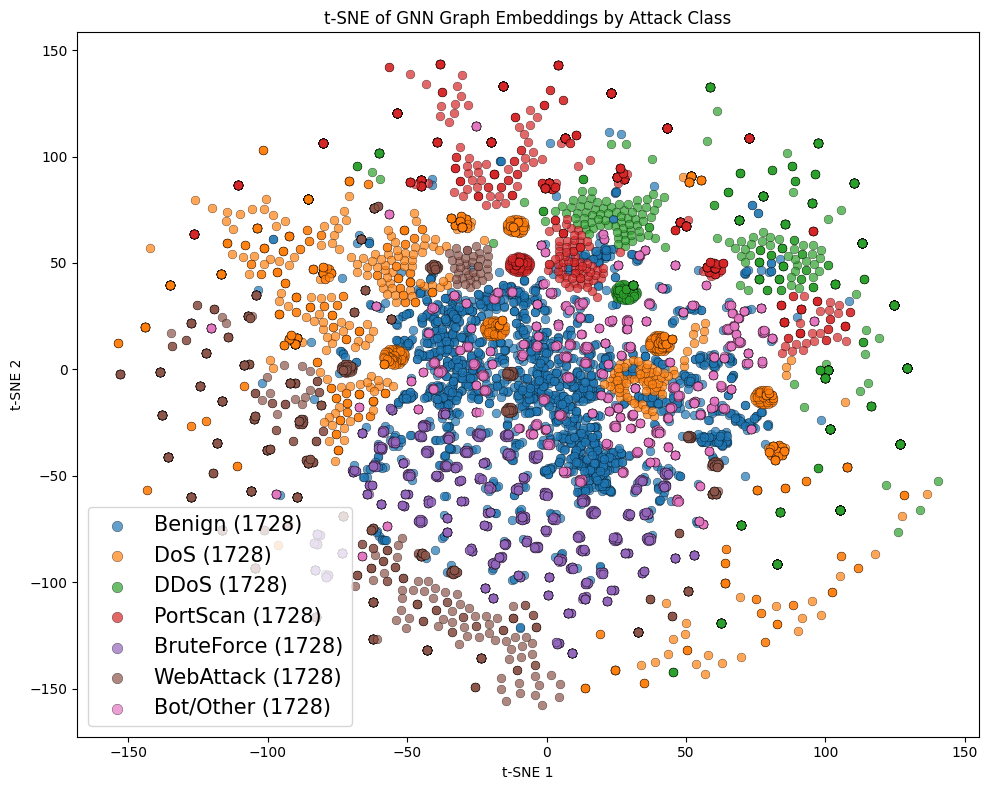

Plotted 12096 graphs, 7 classes


In [12]:
# === t-SNE Visualization ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch_geometric.nn import global_mean_pool

id_to_attack = {0: "Benign", 1: "DoS", 2: "DDoS", 3: "PortScan", 4: "BruteForce", 5: "WebAttack", 6: "Bot/Other"}

@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    all_embs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        node_emb = model.encoder(batch.x, batch.edge_index)  # [N, 128]
        graph_emb = global_mean_pool(node_emb, batch.batch)   # [batch_size, 128]
        all_embs.append(graph_emb.cpu().numpy())
        all_labels.extend(batch.y_attack.squeeze().cpu().tolist())
    return np.concatenate(all_embs), np.array(all_labels)

# Extract from val + test (or use train_loader for training set)
embs, labels = extract_embeddings(model, train_loader)



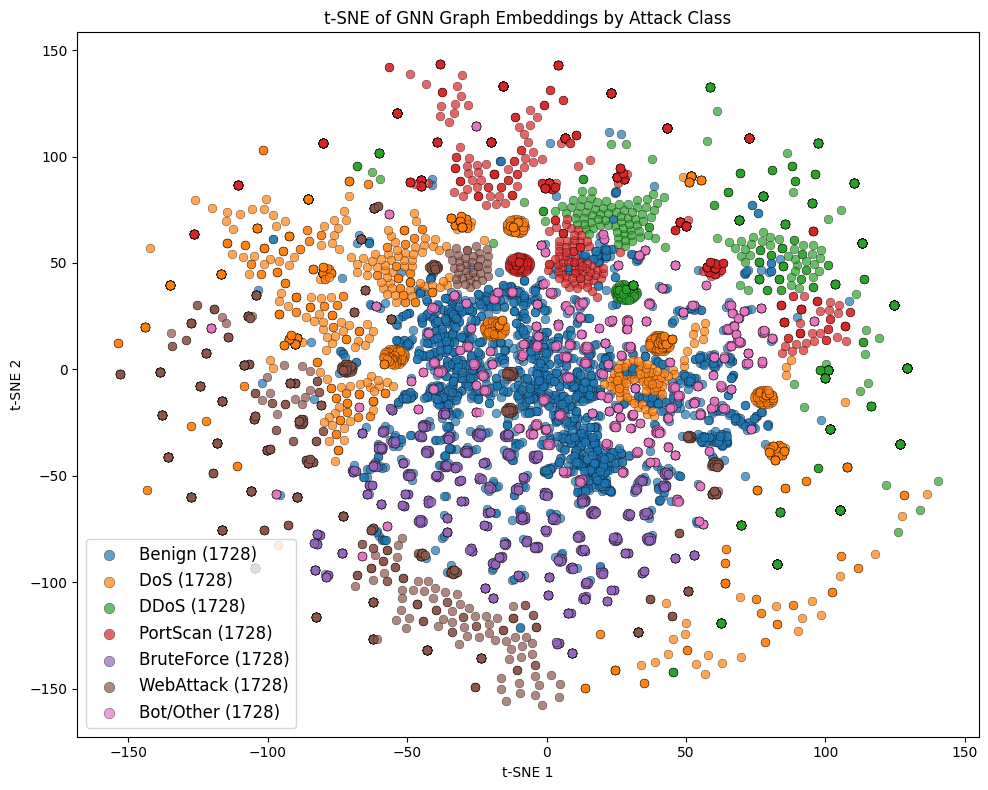

Plotted 12096 graphs, 7 classes


In [14]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=min(30, len(embs)-1), random_state=42, max_iter=1000)
coords = tsne.fit_transform(embs)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

unique_labels = sorted(set(labels))
for cls in unique_labels:
    mask = labels == cls
    name = id_to_attack.get(cls, f"Class {cls}")
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[colors[cls]], label=f"{name} ({mask.sum()})",
               alpha=0.7, s=40, edgecolors='k', linewidths=0.3)

ax.legend(fontsize=12, markerscale=1.2)
ax.set_title("t-SNE of GNN Graph Embeddings by Attack Class")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("tsne_attack_classes.png", dpi=150)
plt.show()
print(f"Plotted {len(embs)} graphs, {len(unique_labels)} classes")

In [16]:
plt.savefig("tsne-stage1.png")

<Figure size 640x480 with 0 Axes>